# Sensor Baseline Model Training and Evaluation

# Conclusion

This project explored multimodal deep learning for plant disease detection using image data and simulated environmental sensor data.

Three separate models were developed and evaluated:

- Image-based CNN model using ResNet18
- Sensor-based neural network
- Fusion model combining image and sensor features

Results showed that the image-based model achieved the highest performance with approximately 91% accuracy, while the sensor-only model performed significantly worse. The multimodal fusion model achieved competitive performance near 90%, demonstrating that image data was the dominant contributor for disease classification in this dataset.

The project demonstrates:
- Deep learning model training
- Transfer learning with ResNet18
- Multimodal data fusion
- Performance evaluation using accuracy, precision, recall, and F1-score
- Visualization using confusion matrices and comparison graphs

Future improvements may include:
- Using real IoT sensor data
- Better feature engineering for sensor inputs
- Attention-based fusion architectures
- Larger and more diverse datasets

## Confusion Matrix

The confusion matrix visualizes classification performance across all plant disease categories.

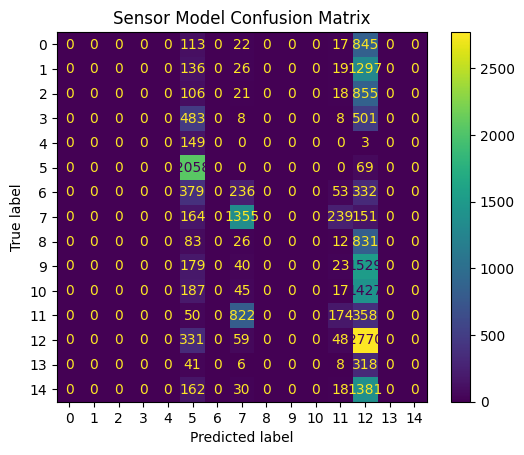

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Sensor Model Confusion Matrix")

plt.savefig("../results/sensor_confusion_matrix.png")

plt.show()

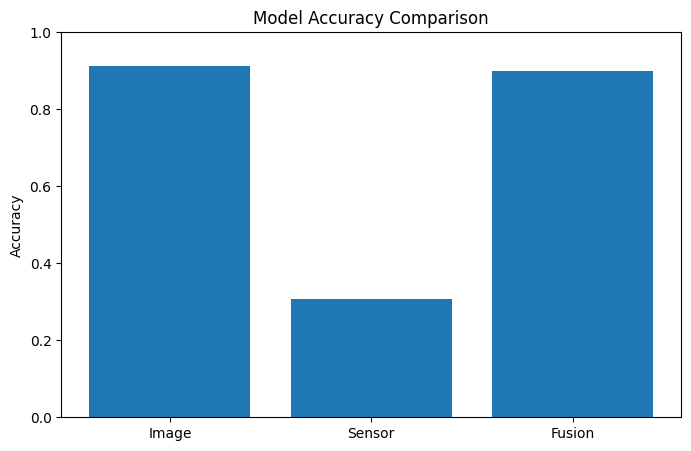

In [23]:
import matplotlib.pyplot as plt

models = [
    "Image",
    "Sensor",
    "Fusion"
]

accuracies = [
    0.9128,
    0.3080,
    0.9000
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

plt.savefig("../results/model_accuracy_comparison.png")

plt.show()

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Image Model",
        "Sensor Model",
        "Fusion Model"
    ],
    "Accuracy": [
        0.9128,
        0.3080,
        0.9000
    ],
    "Precision": [
        0.9244,
        0.1445,
        0.9242
    ],
    "Recall": [
        0.9128,
        0.3080,
        0.9000
    ],
    "F1 Score": [
        0.9121,
        0.1830,
        0.9016
    ]
})

print(comparison)

          Model  Accuracy  Precision  Recall  F1 Score
0   Image Model    0.9128     0.9244  0.9128    0.9121
1  Sensor Model    0.3080     0.1445  0.3080    0.1830
2  Fusion Model    0.9000     0.9242  0.9000    0.9016


## Evaluation Metrics

This section evaluates model performance using:
- Accuracy
- Precision
- Recall
- F1 Score

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.3080
Precision: 0.1445
Recall: 0.3080
F1 Score: 0.1830


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
all_preds = []
all_labels = []

sensor_model.eval()

with torch.no_grad():

    for sensors, labels in sensor_loader:

        sensors = sensors.to(device)
        labels = labels.to(device)

        outputs = sensor_model(sensors)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Evaluation complete")

Evaluation complete


In [17]:
torch.save(
    sensor_model.state_dict(),
    "sensor_model.pth"
)

print("Sensor model saved!")

Sensor model saved!


In [16]:
correct = 0
total = 0

with torch.no_grad():

    for sensors, targets in sensor_loader:

        outputs = sensor_model(sensors)

        _, predicted = torch.max(outputs,1)

        total += targets.size(0)

        correct += (predicted == targets).sum().item()

accuracy = 100 * correct / total

print(f"Sensor Accuracy: {accuracy:.2f}%")

Sensor Accuracy: 30.80%


## Model Training

This section trains the neural network model using the selected dataset and architecture.

In [15]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    sensor_model.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for sensors, targets in sensor_loader:

        optimizer.zero_grad()

        outputs = sensor_model(sensors)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}"
    )

print("Training complete")

Epoch 1/5, Loss: 762.7572
Epoch 2/5, Loss: 709.6458
Epoch 3/5, Loss: 697.4867
Epoch 4/5, Loss: 692.9323
Epoch 5/5, Loss: 690.0764
Training complete


In [14]:
import torch.nn as nn

sensor_model = nn.Sequential(
    nn.Linear(4,64),
    nn.ReLU(),

    nn.Linear(64,32),
    nn.ReLU(),

    nn.Linear(32,15)
)

print(sensor_model)

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=15, bias=True)
)


In [13]:
from torch.utils.data import TensorDataset, DataLoader

sensor_dataset = TensorDataset(
    X,
    labels
)

sensor_loader = DataLoader(
    sensor_dataset,
    batch_size=64,
    shuffle=True
)

print("Batches:", len(sensor_loader))

Batches: 323


In [12]:
from torchvision import datasets, transforms
import torch

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/images/plantvillage/PlantVillage",
    transform=transform
)

labels = torch.tensor(dataset.targets)

print(labels.shape)
print(labels[:10])

torch.Size([20638])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [11]:
min_size = min(len(X), len(labels))

X = X[:min_size]
labels = labels[:min_size]

In [10]:
from sklearn.preprocessing import StandardScaler
import torch

features = df[
    [
        "temperature",
        "humidity",
        "soil_moisture",
        "light_level"
    ]
]

scaler = StandardScaler()

X = torch.tensor(
    scaler.fit_transform(features),
    dtype=torch.float32
)

In [9]:
df = pd.read_csv("../data/generated/sensor_data.csv")

In [8]:
import os
import random
import pandas as pd

image_dir="../data/images/plantvillage/PlantVillage"

rows=[]

for folder in os.listdir(image_dir):

    folder_path=os.path.join(image_dir,folder)

    if os.path.isdir(folder_path):

        for image in os.listdir(folder_path):

            if "Late_blight" in folder:

                temp=random.randint(15,24)
                humidity=random.randint(80,95)
                soil=random.randint(60,85)

            elif "healthy" in folder:

                temp=random.randint(22,30)
                humidity=random.randint(40,60)
                soil=random.randint(20,50)

            else:

                temp=random.randint(18,35)
                humidity=random.randint(30,90)
                soil=random.randint(10,80)

            light=random.randint(300,900)

            rows.append({

                "image":image,
                "temperature":temp,
                "humidity":humidity,
                "soil_moisture":soil,
                "light_level":light

            })

df=pd.DataFrame(rows)

df.to_csv(
    "../data/generated/sensor_data.csv",
    index=False
)

print("Generated:",len(df))

Generated: 20639


In [7]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

sensor_model = sensor_model.to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    sensor_model.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):

    sensor_model.train()

    running_loss = 0

    for features, targets in sensor_loader:

        features = features.to(device)
        targets = targets.to(device)

        outputs = sensor_model(features)

        loss = loss_fn(
            outputs,
            targets
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {running_loss:.4f}"
    )

print("Training complete")

Epoch 1/5, Loss: 836.7629
Epoch 2/5, Loss: 829.3344
Epoch 3/5, Loss: 828.9212
Epoch 4/5, Loss: 828.7472
Epoch 5/5, Loss: 828.4554
Training complete


In [6]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

sensor_dataset = TensorDataset(
    X,
    labels
)

sensor_loader = DataLoader(
    sensor_dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset ready")

print("Batches:", len(sensor_loader))

Dataset ready
Batches: 323


In [5]:
from torchvision import datasets, transforms
import torch

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/images/plantvillage/PlantVillage",
    transform=transform
)

labels = torch.tensor(dataset.targets)

# Make sure X and labels have same size
min_size = min(len(X), len(labels))

X = X[:min_size]
labels = labels[:min_size]

print("Sensor shape:", X.shape)
print("Label shape:", labels.shape)

print("\nFirst labels:")
print(labels[:10])

Sensor shape: torch.Size([20638, 4])
Label shape: torch.Size([20638])

First labels:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [4]:
import torch.nn as nn

sensor_model = nn.Sequential(

    nn.Linear(4,64),
    nn.ReLU(),

    nn.Linear(64,32),
    nn.ReLU(),

    nn.Linear(32,15)

)

print(sensor_model)

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=15, bias=True)
)


In [3]:
import torch
from sklearn.preprocessing import StandardScaler

features = df[
    [
        "temperature",
        "humidity",
        "soil_moisture",
        "light_level"
    ]
]

scaler = StandardScaler()

X = scaler.fit_transform(features)

X = torch.tensor(
    X,
    dtype=torch.float32
)

print(X.shape)

print(X[:5])

torch.Size([20639, 4])
tensor([[-1.0664,  1.7123, -1.3707,  0.2282],
        [ 0.6731,  0.8594,  1.5595,  1.1906],
        [-0.1000, -0.0503, -1.4195, -1.0721],
        [-1.4529, -0.9031,  1.3641, -1.5132],
        [ 0.4798, -0.8463, -1.5661,  1.5401]])


In [2]:
import pandas as pd

df = pd.read_csv("../data/generated/sensor_data.csv")

print(df.shape)

print(df.head())

(20639, 5)
                                               image  temperature  humidity  \
0  38bd9a88-970a-4480-8bc7-12824ac87ff5___Crnl_L....           21        90   
1  5467ad1f-7db3-4b4d-907a-12ea50ef84c3___Crnl_L....           30        75   
2  ea19d516-b7fd-45c3-a459-68281f3bd9aa___Crnl_L....           26        59   
3  b8fc0a5c-ffce-488e-ae68-f4a268f8817b___Crnl_L....           19        44   
4  58fb4710-c0a7-4a76-8667-07fbe66bfac9___Crnl_L....           29        45   

   soil_moisture  light_level  
0             17          638  
1             77          806  
2             16          411  
3             73          334  
4             13          867  


In [1]:
import os
import random
import pandas as pd

image_dir = "../data/images/plantvillage/PlantVillage"

rows = []

for folder in os.listdir(image_dir):

    folder_path = os.path.join(
        image_dir,
        folder
    )

    if os.path.isdir(folder_path):

        for image in os.listdir(folder_path):

            rows.append({

                "image": image,

                "temperature": random.randint(18,35),

                "humidity": random.randint(30,90),

                "soil_moisture": random.randint(10,80),

                "light_level": random.randint(300,900)

            })

df = pd.DataFrame(rows)

print("Generated:", len(df))

df.to_csv(
    "../data/generated/sensor_data.csv",
    index=False
)

Generated: 20639
